正在載入 DINOv3 模型...


Using cache found in /home/U116med/.cache/torch/hub/facebookresearch_dinov3_main


正在提取特徵...
正在執行 K-Means 叢集 (K=8)...


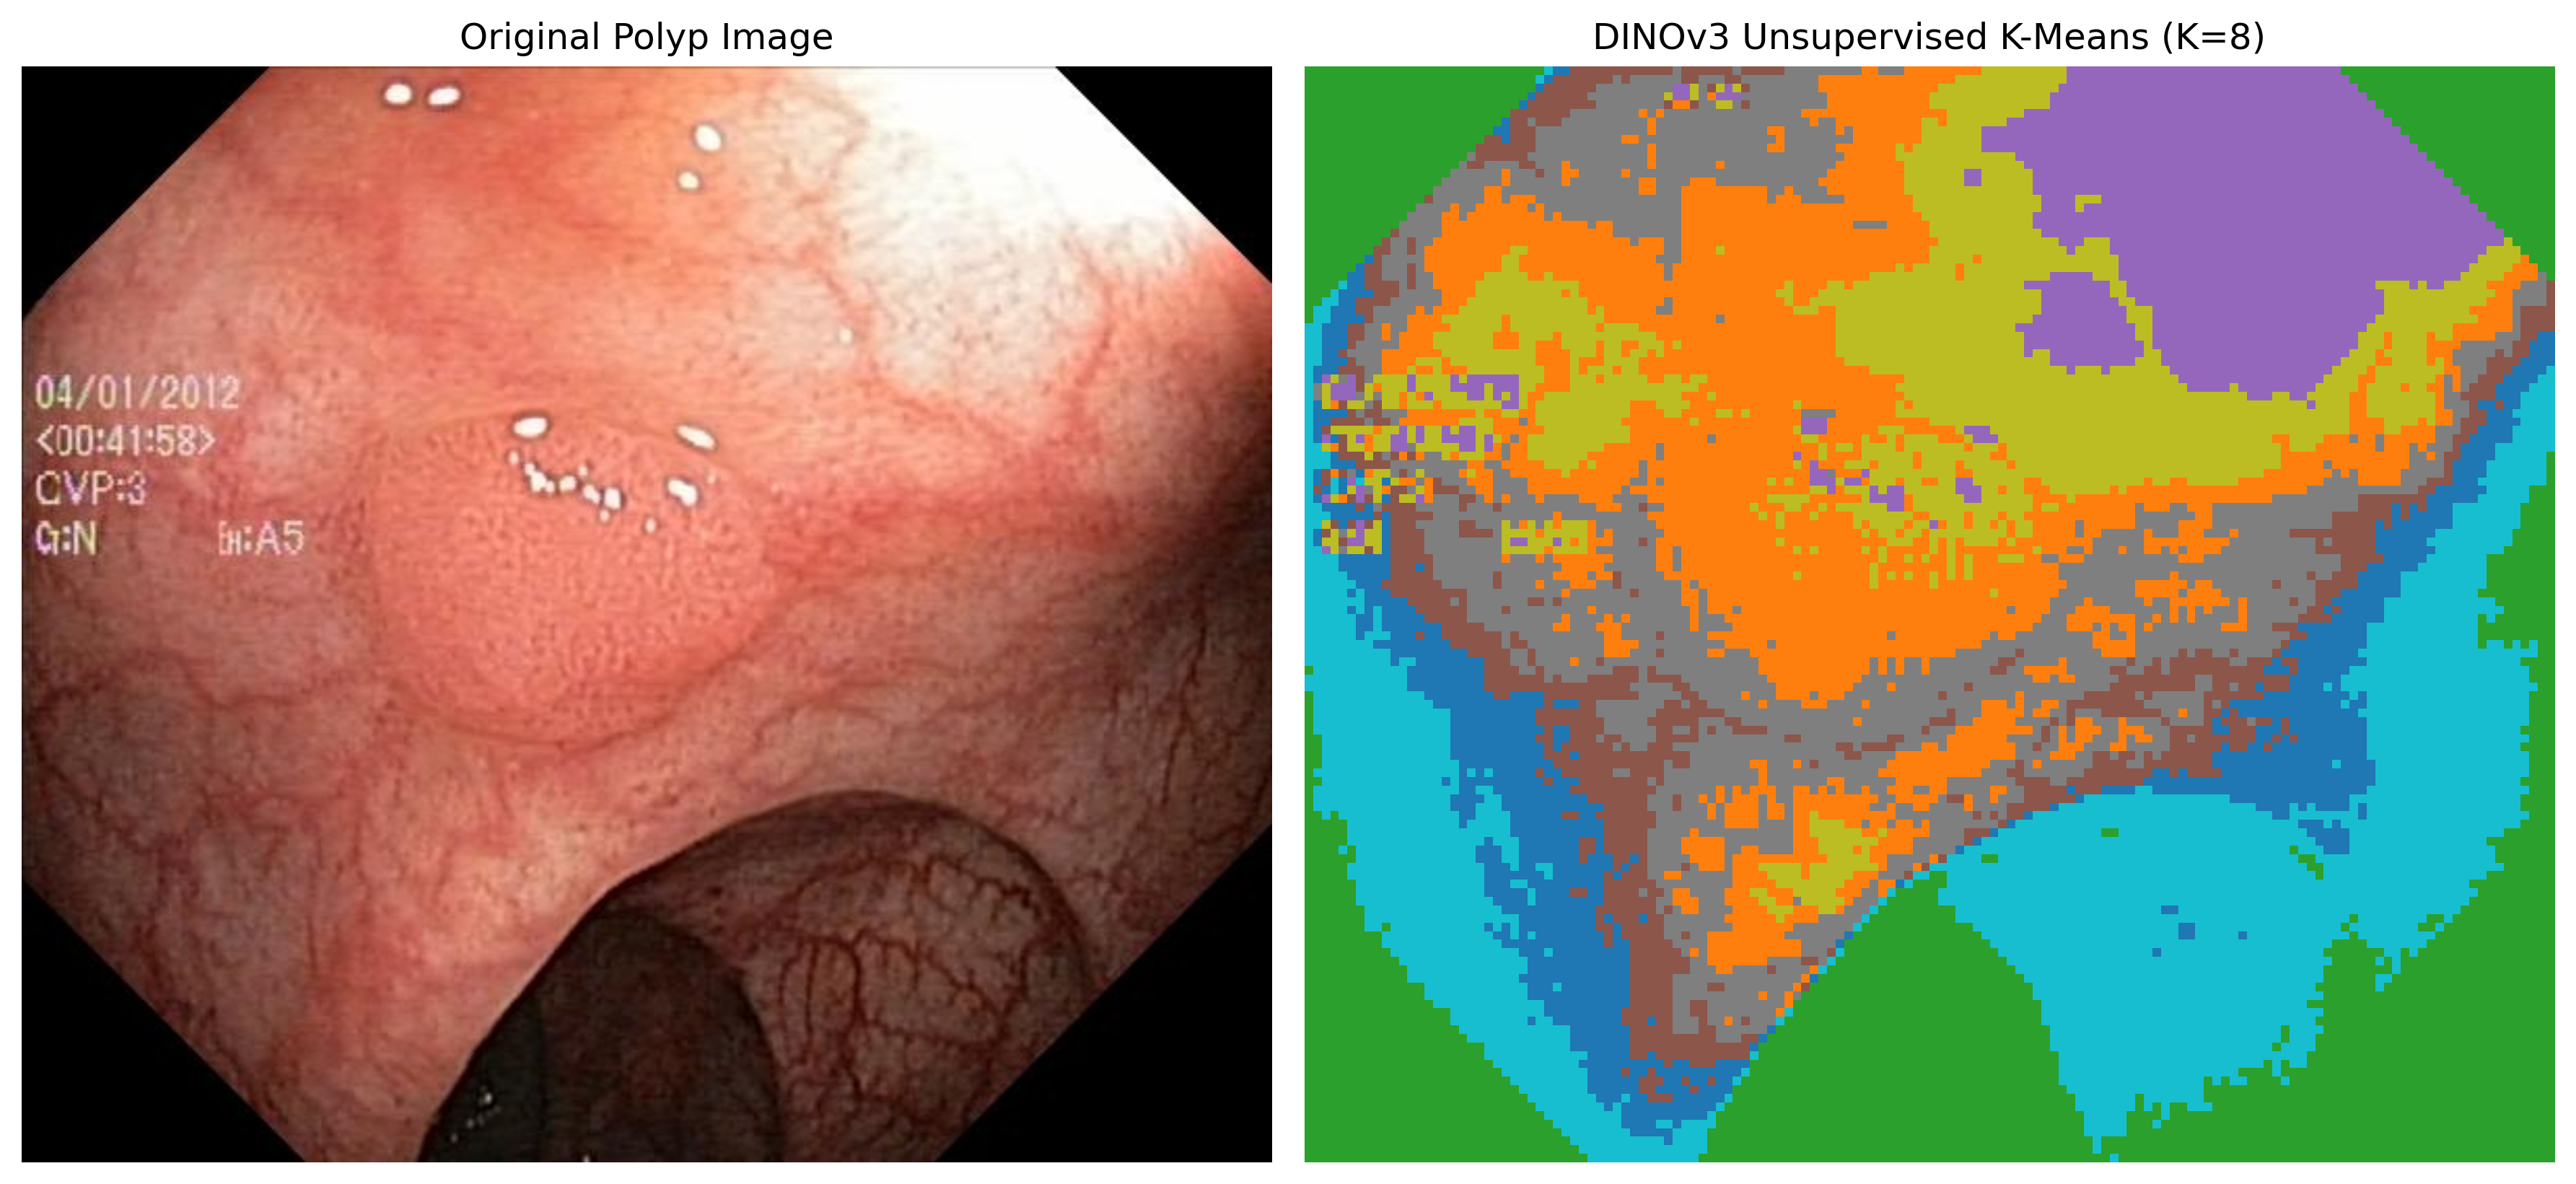

In [5]:
import torch
import torchvision.transforms.functional as TF
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# ==========================================
# 1. 參數設定與模型載入
# ==========================================
PATCH_SIZE = 16
IMAGE_SIZE = 2048  
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# K-Means 群集數量設定 (您可以根據腸道影像的複雜度調整，通常 3~5 之間最合適)
# 假設設定為 4：可能對應到 息肉、正常腸壁、反光、黑色死角
NUM_CLUSTERS = 8

# 請修改為您的本地路徑
CUSTOM_WEIGHT_PATH = "/home/U116med/wch_code/dino_v3/models/prototype_cascade/vits16plus/baseline_prototype_fb_44_fine/best.pth"
LOCAL_IMAGE_PATH = "/home/U116med/data/polyp/TestDataset/Kvasir/images/cju5clr68b48r0755cmuvponm.png"

print("正在載入 DINOv3 模型...")
model = torch.hub.load('facebookresearch/dinov3', 'dinov3_vits16plus', source='github', pretrained=False)
model.load_state_dict(torch.load(CUSTOM_WEIGHT_PATH, map_location="cpu"), strict=False)
model.cuda().eval()

# ==========================================
# 2. 影像讀取與前處理
# ==========================================
if not os.path.exists(LOCAL_IMAGE_PATH):
    raise FileNotFoundError(f"找不到指定的影像檔案: {LOCAL_IMAGE_PATH}")

image = Image.open(LOCAL_IMAGE_PATH).convert("RGB")
w, h = image.size
h_patches = int(IMAGE_SIZE / PATCH_SIZE)
w_patches = int((w * IMAGE_SIZE) / (h * PATCH_SIZE))

image_resized = TF.to_tensor(TF.resize(image, (h_patches * PATCH_SIZE, w_patches * PATCH_SIZE)))
image_resized_norm = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

# ==========================================
# 3. 提取 DINOv3 空間特徵 (全圖)
# ==========================================
print("正在提取特徵...")
with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0).cuda(), n=1, reshape=True, norm=True)
        x = feats[0].squeeze(0).cpu()
        
        c, hp, wp = x.shape
        x_flat = x.view(c, -1).permute(1, 0).numpy() # shape: (hp*wp, 384)

# ==========================================
# 4. 執行 K-Means 叢集分析
# ==========================================
print(f"正在執行 K-Means 叢集 (K={NUM_CLUSTERS})...")
# 使用 sklearn 的 KMeans 模型
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(x_flat) # 輸出每個 token 對應的群組 ID (0, 1, 2, ...)

# 將一維的標籤陣列重塑回二維的影像網格 (H, W)
cluster_image = cluster_labels.reshape(hp, wp)

# ==========================================
# 5. 視覺化對比
# ==========================================
plt.figure(figsize=(12, 6), dpi=300)

plt.subplot(1, 2, 1)
plt.imshow(image_resized.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title("Original Polyp Image")

plt.subplot(1, 2, 2)
# 使用 cmap='tab10' 這種離散型的色階，可以更清楚看到不同群組的邊界
plt.imshow(cluster_image, cmap='tab10')
plt.axis('off')
plt.title(f"DINOv3 Unsupervised K-Means (K={NUM_CLUSTERS})")

plt.tight_layout()
plt.show()